### Start of Test # 2 (19.3.26)

### Import packages

In [169]:
# Created on jan 2025
# https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1012692

# numpy and scipy
import numpy as np
import scipy.stats as stt
import scipy.linalg as spl
import scipy.signal as spsg
import scipy.io as sio
from scipy.signal import welch, find_peaks
import os

# MOU model
from test_MOU_largenet import MOUv2

# classification scikit-learn
import sklearn.linear_model as skllm
import sklearn.preprocessing as skppr
import sklearn.pipeline as skppl
import sklearn.neighbors as sklnn

# plotting
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sb
import pandas as pd

import tqdm

# Import utility functions
from utils import *

#### Set up data parameters

In [170]:
data_dir = './' # data repo
res_dir = './' # results
presentation_figs_dir = 'C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\figs\\test_fit_MOU_Q_3\\'
os.makedirs(presentation_figs_dir, exist_ok=True)
graph_format = 'png' # graph formatting

# data and model parameters
n_sub = 48
N = 68 # number of regions; size of network for AAL90

conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

situation_idx = 1 # set to 0 if using empirical data, to 1 if using data from the Reduced Wong-Wang model 
situations = ['empirical', 'simulated']

# Set number of time shifts for covariances Q
n_tau = 2

In [171]:
# Load data simulated with Reduced Wong-Wang model
#RWW_data_path = "c:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\scripts\\TVBOptim\\results\\simulated_bold.npy"

if situation_idx == 1: # using simulated data
    RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\learning_rate_0.0325_max_steps_300\bold_gd.npy"
    TS_RWW = np.load(RWW_data_path) # for the moment only have controls
    n_subjects_RWW = TS_RWW.shape[0]
    n_conditions_RWW = TS_RWW.shape[-1]
    print(f"Simulated data shape: {TS_RWW.shape}")
    # Separate into CTR and SCZ if using simulated data
    TS_CTR = TS_RWW[:,:,:,0] 
    TS_SCZ = TS_RWW[:,:,:,1] 
    # Load empirical data for comparing and as util for reshaping simulated data
    TS_CTR_emp  = np.load('TS_Control.npy')
    print(f"Empirical data shape: {TS_CTR_emp.shape}")
    # We want to reshape into (n_subjects, n_regions, n_timepoints, n_conditions)
    n_time_points = TS_CTR_emp.shape[-1]
    new_array = TS_RWW.reshape(n_subjects_RWW, N, n_time_points, n_conditions_RWW) 
    print(f"Reshaped simulated data shape: {TS_CTR.shape}")
else:
    TS_CTR = np.load('TS_Control.npy')
    TS_SCZ = np.load('TS_Schizo.npy')
    print(f"Empirical data shape: {TS_CTR.shape}")
    # Separate the participants by condition
    condition_0 = TS_CTR[0:n_sub, 0:N, :]  # all participants (condition 0)
    condition_1 = TS_SCZ[:, 0:N, :]  # Last 48 participants (condition 1)

    # Determine the maximum number of participants in either condition (for alignment)
    max_participants = max(condition_0.shape[2], condition_1.shape[2])

    # Pad the smaller group to match the size of the larger one along the participant dimension
    condition_0_padded = np.pad(condition_0, ((0, 0), (0, 0), (0, max_participants - condition_0.shape[2])), mode='constant')
    condition_1_padded = np.pad(condition_1, ((0, 0), (0, 0), (0, max_participants - condition_1.shape[2])), mode='constant')

    # Stack the conditions along the fourth dimension
    new_array = np.stack((condition_0_padded, condition_1_padded), axis=3)

    print("New array shape:", new_array.shape)

Simulated data shape: (3, 152, 68, 2)
Empirical data shape: (116, 82, 152)
Reshaped simulated data shape: (3, 152, 68)


#### Subsampling data for testing

In [194]:
# Set to one if this is a test run with a few subjects
test_run = 1

if test_run:
    n_sub = 1

### Start of test: using the Q0 and Q1 matrices directly to fit the MOU 

In [197]:
if situation_idx == 1:  # using simulated data
    #data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_3_sub_zscore_True_diagZero_False_diagZeroQ0_True_2"
    data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_1_sub_zscore_False_diagZero_False_corrected"
    Q0_file_name = "Q0_sim.npy"
    Q1_file_name = "Q1_sim.npy"

    Q0_file_path = os.path.join(data_path, Q0_file_name)
    Q1_file_path = os.path.join(data_path, Q1_file_name)

    Q0 = np.load(Q0_file_path)
    Q1 = np.load(Q1_file_path)
    print("Shape should be (n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q0.shape}") 
    print(f"Q1 shape: {Q1.shape}")

    ## Test : add identity (as if there was diag_zero = False)
    for participant_idx in range(n_sub):
        for condition_idx in range(n_cond):
            Q0[participant_idx, :, :, condition_idx] =  Q0[participant_idx, :, :, condition_idx] + np.eye(N)[None, :, :]
            #Q1[participant_idx, :, :, condition_idx] =  Q1[participant_idx, :, :, condition_idx] + np.eye(N)[None, :, :]

    Q_data = np.stack([Q0, Q1], axis=0)
else:
    Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
    Q1 = np.zeros((n_sub, N, N, n_cond))
    for participant_idx in range(n_sub):
        for condition_idx in range(n_cond):
            # Get empirical time series of interest 
            ts = new_array[participant_idx,:,:,condition_idx]
            # Take the transpose for the lagged FC matrices computation
            X_emp = ts.T

            # Compute empirical lagged FC matrices
            Q_emp_single = lagged_fc_matrices(X_emp, n_tau=n_tau, diag_zero=False)
            Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
            Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

            Q0[participant_idx, :, :, condition_idx] = Q0_emp_single 
            Q1[participant_idx, :, :, condition_idx] = Q1_emp_single
    Q_data = np.stack([Q0, Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
    print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q_data.shape}")
    

Shape should be (n_subjects, n_regions, n_regions, n_conditions):
Q0 shape: (1, 68, 68, 2)
Q1 shape: (1, 68, 68, 2)


In [81]:
Q_data.shape

(2, 3, 68, 68, 2)

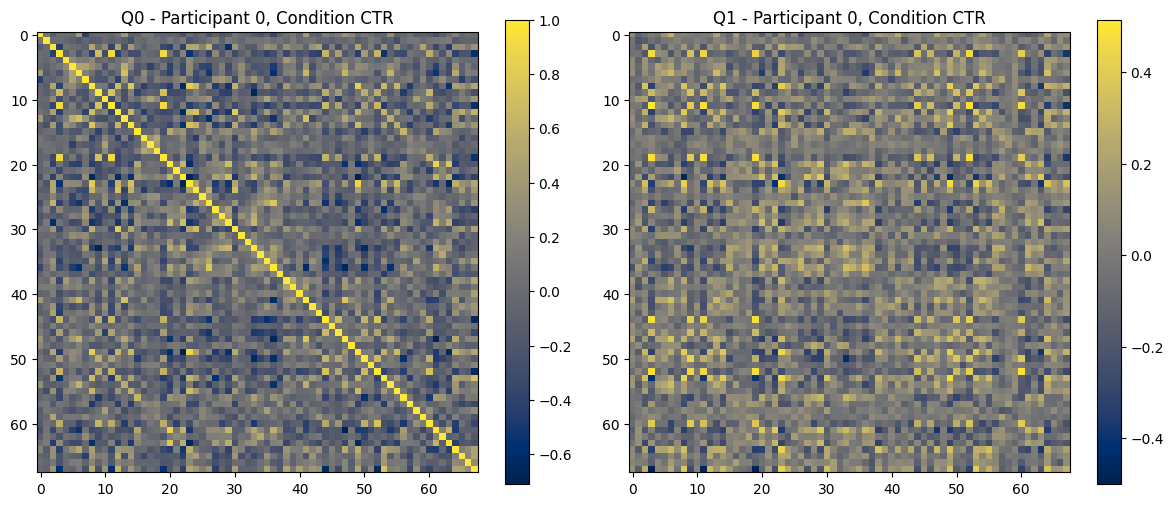

In [174]:
# Plot for one participant and condition
participant_plot = 0   
cond_plot = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(Q_data[0, participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Q0 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(Q_data[1,participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Q1 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.tight_layout()
plt.show()

### End of test

### Start of test 2.0 : compare correlation Q0_emp/Q0_sim and Q1_emp/Q1_sim here to the ones in the results/ folder in TVBOptim

In [198]:
### TEST ; compute correlations 

#RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_3_sub_zscore_True_diagZero_False_diagZeroQ0_True_2"
RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_1_sub_zscore_False_diagZero_False_corrected"
RWW_Q0_file_name = "Q0_sim.npy"
RWW_Q1_file_name = "Q1_sim.npy"

Q0_file_path = os.path.join(RWW_data_path, RWW_Q0_file_name)
Q1_file_path = os.path.join(RWW_data_path, RWW_Q1_file_name)

RWW_Q0 = np.load(Q0_file_path)
RWW_Q1 = np.load(Q1_file_path)
print("Shape should be (n_subjects, n_regions, n_regions, n_conditions):")
print(f"Q0 shape: {RWW_Q0.shape}") 
print(f"Q1 shape: {RWW_Q1.shape}")

## Test : add identity (as if there was diag_zero = False)
for participant_idx in range(n_sub):
    for condition_idx in range(n_cond):
        RWW_Q0[participant_idx, :, :, condition_idx] =  RWW_Q0[participant_idx, :, :, condition_idx] + np.eye(N)[None, :, :]

RWW_Q_data = np.stack([RWW_Q0, RWW_Q1], axis=0)
print("Simulated data shape:")
print(f"RWW_Q_data shape: {RWW_Q_data.shape}")

## Empirical data
TS_CTR = np.load('TS_Control.npy')
TS_SCZ = np.load('TS_Schizo.npy')
print(f"Empirical data shape: {TS_CTR.shape}")
# Separate the participants by condition
condition_0 = TS_CTR[0:n_sub, 0:N, :]  # all participants (condition 0)
condition_1 = TS_SCZ[0:n_sub, 0:N, :]  # Last 48 participants (condition 1)

# Determine the maximum number of participants in either condition (for alignment)
max_participants = max(condition_0.shape[2], condition_1.shape[2])

# Pad the smaller group to match the size of the larger one along the participant dimension
condition_0_padded = np.pad(condition_0, ((0, 0), (0, 0), (0, max_participants - condition_0.shape[2])), mode='constant')
condition_1_padded = np.pad(condition_1, ((0, 0), (0, 0), (0, max_participants - condition_1.shape[2])), mode='constant')

# Stack the conditions along the fourth dimension
new_array = np.stack((condition_0_padded, condition_1_padded), axis=3)

emp_Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
emp_Q1 = np.zeros((n_sub, N, N, n_cond))
for participant_idx in range(n_sub):
    for condition_idx in range(n_cond):
        # Get empirical time series of interest 
        ts = new_array[participant_idx,:,:,condition_idx]
        # Take the transpose for the lagged FC matrices computation
        X_emp = ts.T

        ## Test: add z-scoring and see how that goes
        # Z-score the empirical time series per region
        z_scored_emp = z_score_per_region(X_emp)
        ## End of test 

        # Compute empirical lagged FC matrices
        Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=False)
        emp_Q0[participant_idx, :, :, condition_idx] = Q_emp_single[0] 
        emp_Q1[participant_idx, :, :, condition_idx] = Q_emp_single[1]  # FC1 (lag-1)

        # Normalize the empirical FC matrices by their maximum absolute value
        # emp_Q0[participant_idx, :, :, condition_idx] /= np.max(np.abs(emp_Q0[participant_idx, :, :, condition_idx]))
        # emp_Q1[participant_idx, :, :, condition_idx] /= np.max(np.abs(emp_Q1[participant_idx, :, :, condition_idx]))

emp_Q_data = np.stack([emp_Q0, emp_Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
print(f"emp_Q0 shape: {emp_Q_data.shape}")

Shape should be (n_subjects, n_regions, n_regions, n_conditions):
Q0 shape: (1, 68, 68, 2)
Q1 shape: (1, 68, 68, 2)
Simulated data shape:
RWW_Q_data shape: (2, 1, 68, 68, 2)
Empirical data shape: (116, 82, 152)
Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):
emp_Q0 shape: (2, 1, 68, 68, 2)


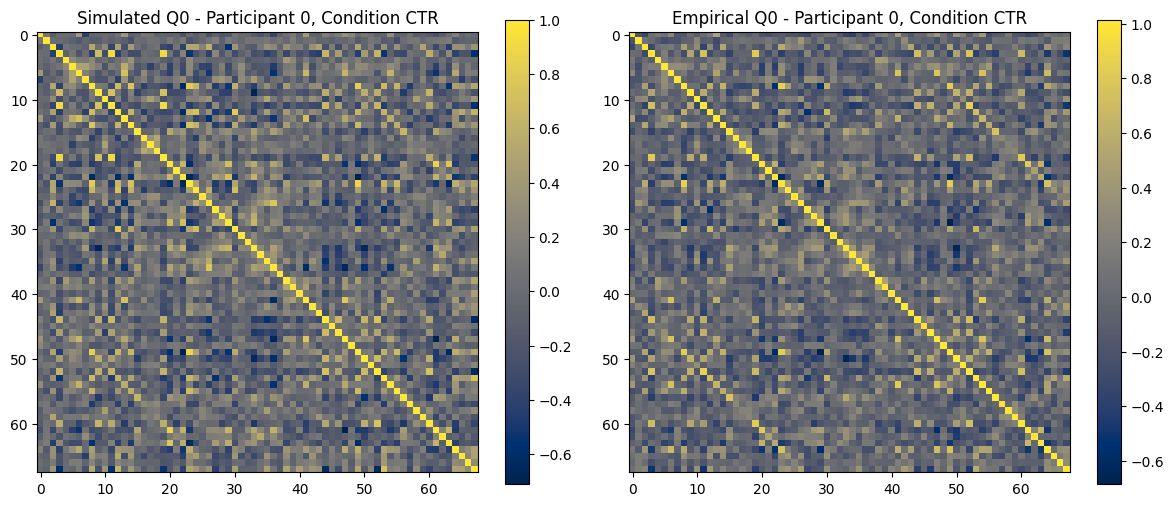

In [176]:
# Plot for one participant and condition
participant_plot = 0   
cond_plot = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(RWW_Q0[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Simulated Q0 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(emp_Q0[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Empirical Q0 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.tight_layout()
plt.show()

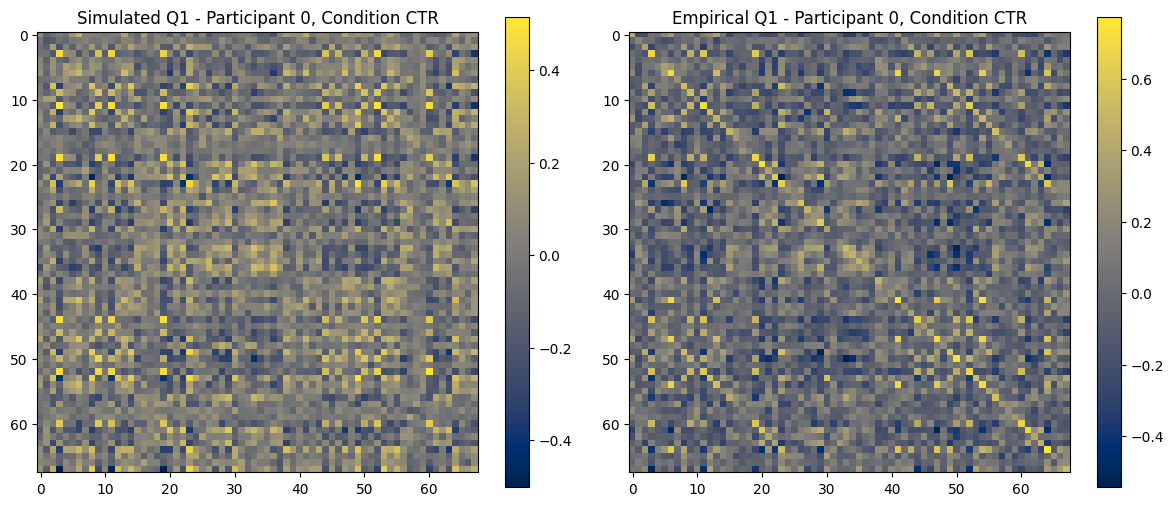

In [177]:
# Plot for one participant and condition
participant_plot = 0   
cond_plot = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(RWW_Q1[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Simulated Q1 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(emp_Q1[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Empirical Q1 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.tight_layout()
plt.show()

Participant 0, Condition 0:
Correlation for Q0: 0.9070
Correlation for Q1: 0.8018


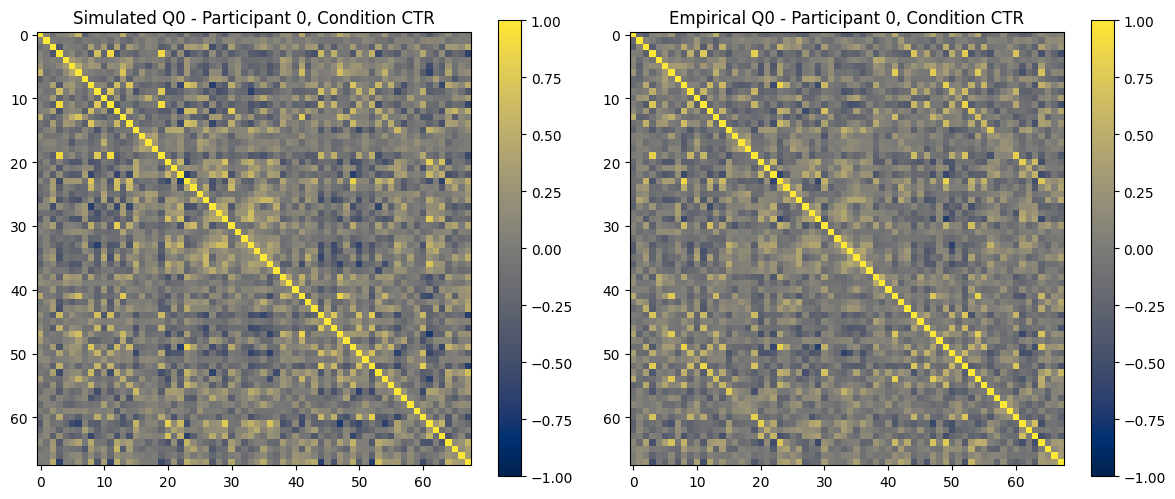

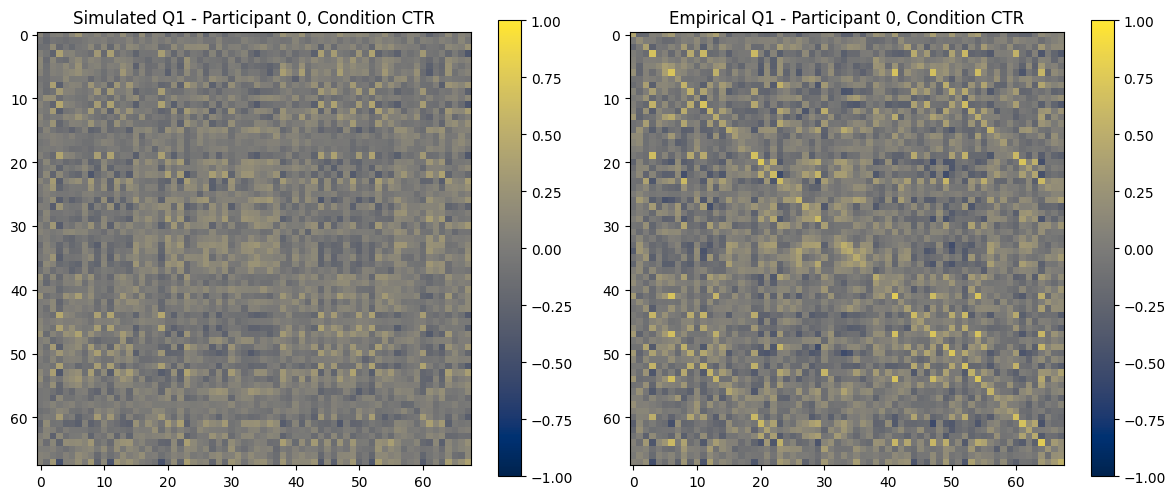

Participant 0, Condition 1:
Correlation for Q0: 0.9176
Correlation for Q1: 0.8110


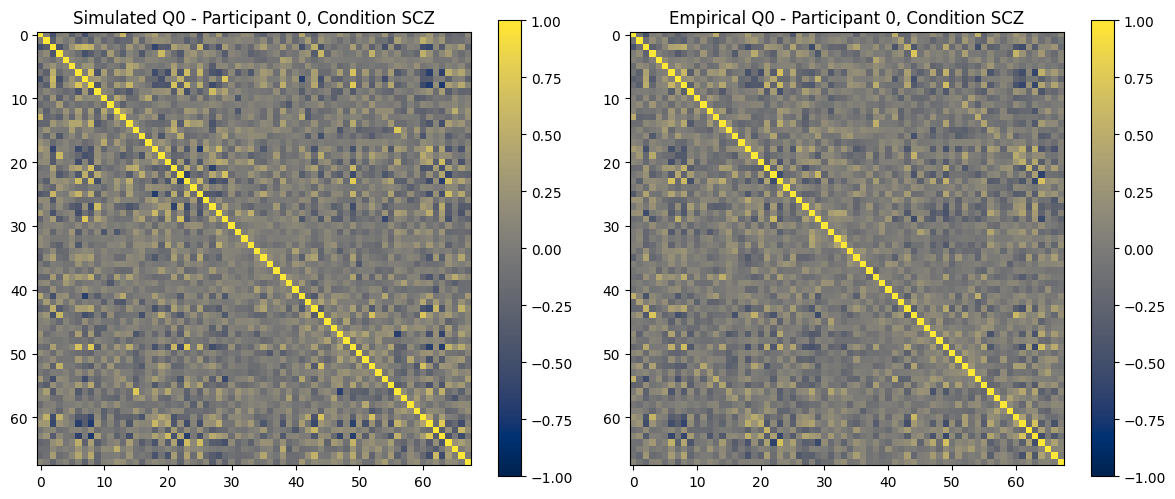

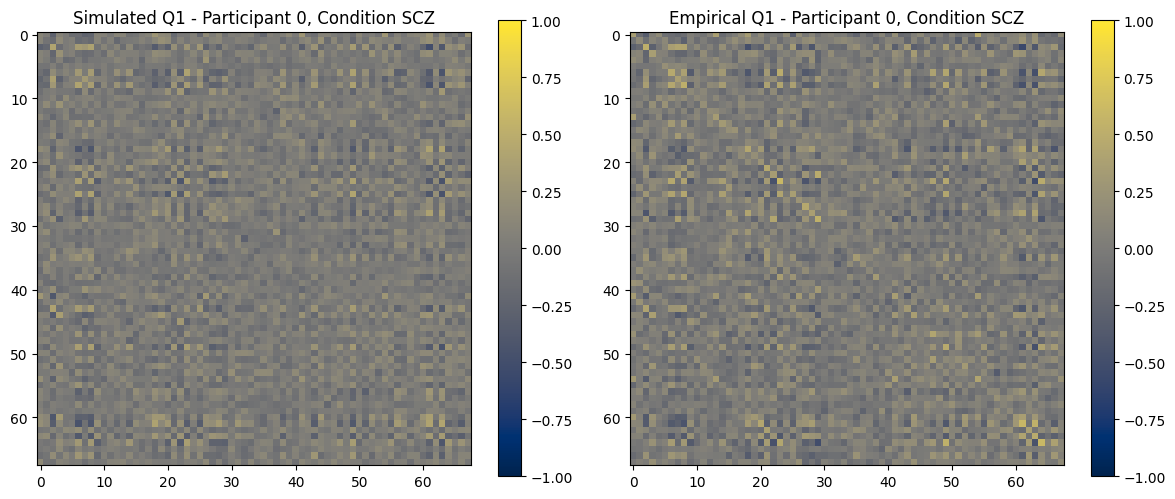

In [205]:
## Compute correlations between simulated and empirical FC0 and FC1 matrices for each participant and condition
for participant_idx in range(n_sub):
    for condition_idx in range(n_cond):
        correlation_Q0_temp = np.corrcoef(RWW_Q0[participant_idx, :, :, condition_idx].flatten(), emp_Q0[participant_idx, :, :, condition_idx].flatten())
        correlation_Q1_temp = np.corrcoef(RWW_Q1[participant_idx, :, :, condition_idx].flatten(), emp_Q1[participant_idx, :, :, condition_idx].flatten())
        print(f"Participant {participant_idx}, Condition {condition_idx}:")
        print(f"Correlation for Q0: {correlation_Q0_temp[0, 1]:.4f}")
        print(f"Correlation for Q1: {correlation_Q1_temp[0, 1]:.4f}")
        # Plot Q0
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(RWW_Q0[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Simulated Q0 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.subplot(1, 2, 2)
        plt.imshow(emp_Q0[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Empirical Q0 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()
        # Plot Q1 
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(RWW_Q1[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Simulated Q1 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.subplot(1, 2, 2)
        plt.imshow(emp_Q1[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Empirical Q1 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

### End of test 2.0

### Start of test 3.0 : using z_scored empirical data for fitting the MOU

In [35]:
test_zscore_emp = 1

if (situation_idx == 0) & (test_zscore_emp == 1): 
    Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
    Q1 = np.zeros((n_sub, N, N, n_cond))
    for participant_idx in range(n_sub):
        for condition_idx in range(n_cond):
            # Get empirical time series of interest 
            ts = new_array[participant_idx,:,:,condition_idx]
            # Take the transpose for the lagged FC matrices computation
            X_emp = ts.T
                
            # Z-score the empirical time series per region
            z_scored_emp = z_score_per_region(X_emp)

            # Compute empirical lagged FC matrices
            Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=False)
            Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
            Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

            Q0[participant_idx, :, :, condition_idx] = Q0_emp_single
            Q1[participant_idx, :, :, condition_idx] = Q1_emp_single
    Q_data = np.stack([Q0, Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
    print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q_data.shape}")

Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):
Q0 shape: (2, 3, 68, 68, 2)


### End of test 3.0

### Start of test 4.0 : change  diagonal of empirical matrices from z-scored time-series; Q0 to one and Q1 to zero

In [41]:
test_diags_change = 1

if (situation_idx == 0) & (test_diags_change == 1): 
    Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
    Q1 = np.zeros((n_sub, N, N, n_cond))
    for participant_idx in range(n_sub):
        for condition_idx in range(n_cond):
            # Get empirical time series of interest 
            ts = new_array[participant_idx,:,:,condition_idx]
            # Take the transpose for the lagged FC matrices computation
            X_emp = ts.T
                
            # Z-score the empirical time series per region
            z_scored_emp = z_score_per_region(X_emp)

            # Compute empirical lagged FC matrices
            Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=False)
            Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
            Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

            ### test : change diagonals to see if same error
            np.fill_diagonal(Q0_emp_single, val=1) # set diagonals of Q0 to one
            np.fill_diagonal(Q1_emp_single, val=1) # set diagonals of Q1 to zero
            ###

            Q0[participant_idx, :, :, condition_idx] = Q0_emp_single 
            Q1[participant_idx, :, :, condition_idx] = Q1_emp_single
    Q_data = np.stack([Q0, Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
    print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q_data.shape}")

Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):
Q0 shape: (2, 3, 68, 68, 2)


Text(0.5, 1.0, 'Filtered BOLD activity for participant 0 - Condition: CTR')

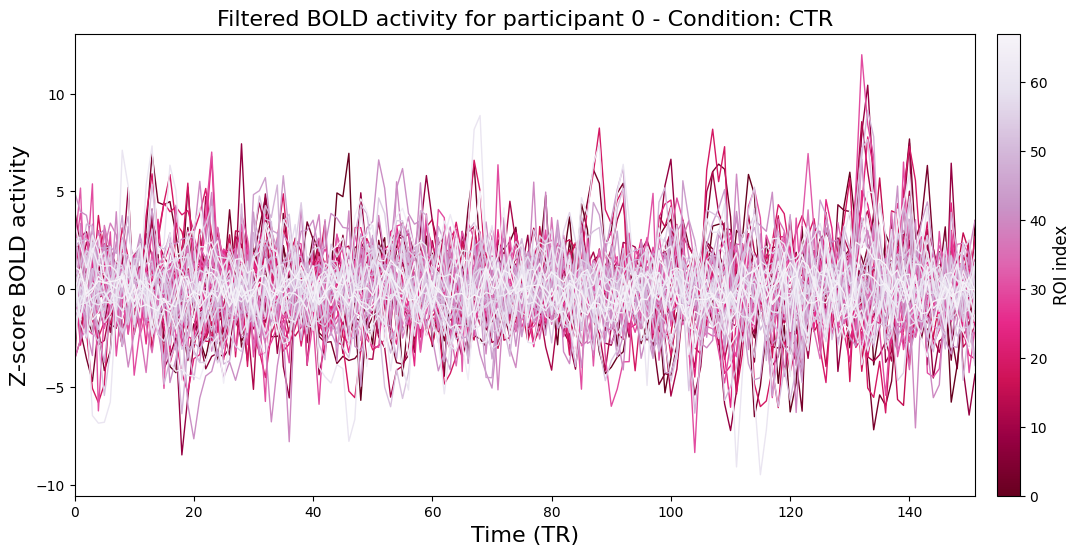

In [69]:
plot_participant = 0
plot_cond = 0 #scz for 1, ctr for 0

cmap = plt.cm.PuRd_r
n_nodes = N
norm = plt.Normalize(vmin=0, vmax=n_nodes - 1)

fig, ax = plt.subplots(figsize=(14,6))

for roi in range(n_nodes):
	ax.plot(
		range(new_array.shape[2]),
		new_array[plot_participant, roi, :, plot_cond], color=cmap(norm(roi)), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('ROI index', fontsize=12)

ax.set_xlim(0, new_array.shape[2] - 1)
ax.set_xlabel('Time (TR)', fontsize=16)
ax.set_ylabel('Z-score BOLD activity', fontsize=16)
ax.set_title(f"Filtered BOLD activity for participant {plot_participant} - Condition: {conds[plot_cond]}", fontsize = 16)


In [27]:
def zscore_check(x, axis=None, thres= 1e-10, verbose=False):
    """Check if the input array is z-scored (mean ~ 0 and std ~ 1) along the specified axis."""
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis, ddof=0)  # ddof=0 matches most z-score implementations
    if verbose:
        print(f"mean ~ 0? max|mean|={np.max(np.abs(mean)):.3e}")
        print(f"std ~ 1? max|std-1|={np.max(np.abs(std-1)):.3e}")
    if np.max(np.abs(mean)) > thres or np.max(np.abs(std-1)) > thres:
        if verbose:
            print(
            f"Signal is not z-scored: mean is not close to 0 or std is not close to 1 "
            f"(max|mean|={np.max(np.abs(mean)):.3e}); max|std-1|={np.max(np.abs(std-1)):.3e})"
                )
        return False 
    
    else: 
        if verbose:
            print(f"Signal is z-scored: mean is close to 0 and std is close to 1 (max|mean|={np.max(np.abs(mean)):.3e}); max|std-1|={np.max(np.abs(std-1)):.3e})")
        return True
    
print("\nChecking if the data is z-scored...")
print(zscore_check(new_array, axis=2, verbose=True))


Checking if the data is z-scored...
mean ~ 0? max|mean|=9.355e-01
std ~ 1? max|std-1|=7.668e-01
Signal is not z-scored: mean is not close to 0 or std is not close to 1 (max|mean|=9.355e-01); max|std-1|=7.668e-01)
False


c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\.venv\lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 152, using nperseg = 152
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Valid ROI peaks: 68/68
Mean peak frequency: 0.0467 Hz
Median peak frequency: 0.0296 Hz


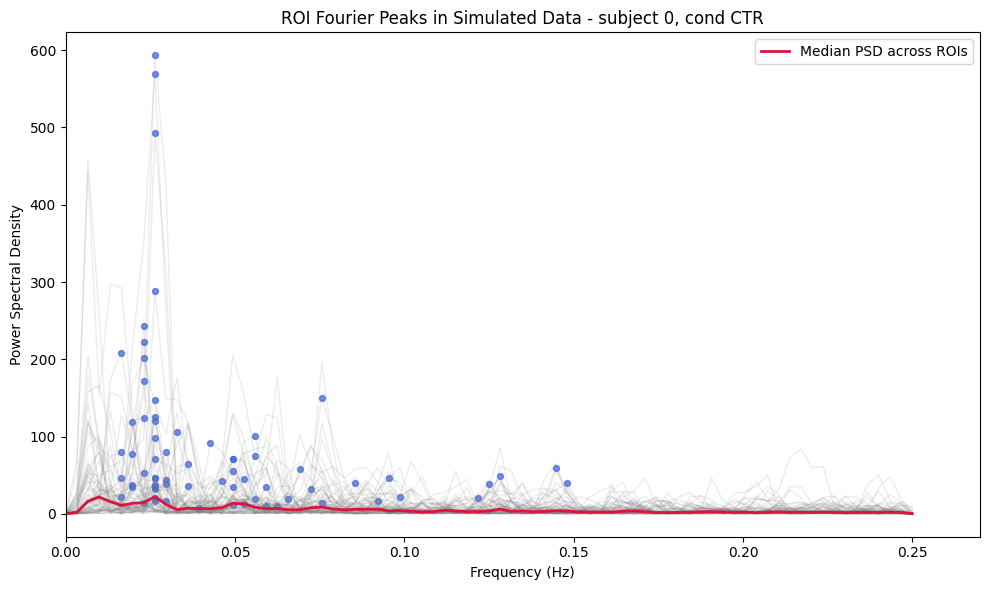

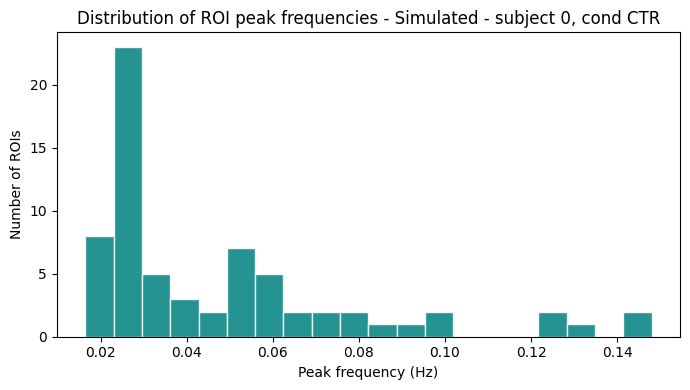

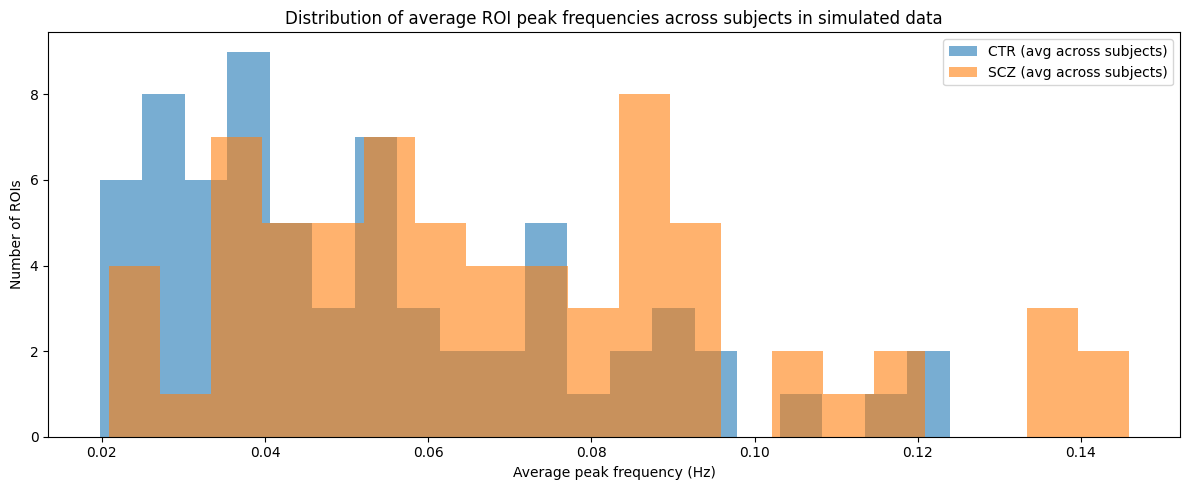

In [70]:
# Fourier peaks per ROI for one subject/condition
# -------- choose data --------
plot_participant = 0
plot_cond = 0  # 0=CTR, 1=SCZ in your setup
X = new_array[plot_participant, :, :, plot_cond]  # shape: [n_rois, n_timepoints]

# -------- compute PSD and dominant peaks --------
def compute_psd_and_peaks(X, TR = 2.0, fmin = 0.01, fmax = 0.25, verbose=True):
    """
    Compute power spectral density (PSD) for each ROI and identify the dominant
    frequency peak within a specified band.

    Parameters
    ----------
    X : ndarray of shape [n_rois, n_timepoints]
        Time series data for each ROI.
    TR : float
        BOLD repetition time in seconds.
    fmin : float
        Minimum frequency of interest in Hz.
    fmax : float
        Maximum frequency of interest in Hz.

    Returns
    -------
    peak_freqs : ndarray of shape [n_rois]
        Dominant frequency peak for each ROI (NaN if no valid peak found).
    peak_powers : ndarray of shape [n_rois]
        Power at the dominant frequency peak for each ROI (NaN if no valid peak found).
    psd_all : ndarray of shape [n_rois, n_freqs]
        Power spectral density for all ROIs across frequencies.
    freqs_ref : ndarray of shape [n_freqs]
        Frequency values corresponding to the PSD estimates.
    """
    fs = 1.0 / TR # sampling frequency in Hz
    n_rois = X.shape[0]
    peak_freqs = np.full(n_rois, np.nan)
    peak_powers = np.full(n_rois, np.nan)
    psd_all = []
    freqs_ref = None

    for r in range(n_rois):
        x = X[r]
        x = x - np.mean(x)  # remove DC
        
        freqs, psd = welch(x, fs=fs)

        if freqs_ref is None:
            freqs_ref = freqs
        psd_all.append(psd)

        band_mask = (freqs >= fmin) & (freqs <= fmax)
        f_band = freqs[band_mask]
        p_band = psd[band_mask]

        if len(p_band) < 3:
            continue

        # candidate local maxima
        pk_idx, _ = find_peaks(p_band)
        if len(pk_idx) == 0:
            # fallback: global max in band
            i_max = np.argmax(p_band)
            peak_freqs[r] = f_band[i_max]
            peak_powers[r] = p_band[i_max]
        else:
            # choose strongest local peak
            best_local = pk_idx[np.argmax(p_band[pk_idx])]
            peak_freqs[r] = f_band[best_local]
            peak_powers[r] = p_band[best_local]

    psd_all = np.array(psd_all)  # shape: [n_rois, n_freqs]
    valid = ~np.isnan(peak_freqs)
    
    if verbose:
        print(f"Valid ROI peaks: {valid.sum()}/{n_rois}")
    
        print(f"Mean peak frequency: {np.nanmean(peak_freqs):.4f} Hz")
        print(f"Median peak frequency: {np.nanmedian(peak_freqs):.4f} Hz")
    
    return peak_freqs, freqs_ref, psd_all


peak_freqs, freqs_ref, psd_all = compute_psd_and_peaks(X, TR=2.0, fmin=0.01, fmax=0.25, verbose=True)

valid = ~np.isnan(peak_freqs)

# Get peaks for all participants and conditions
peak_freqs_all = np.zeros((n_sub, N, n_cond))

for part_temp in range(n_sub):
    for cond_temp in range(n_cond):
        X_temp = new_array[part_temp, :, :, cond_temp]
        peak_freqs_temp,_ , _ = compute_psd_and_peaks(X_temp, TR=2.0, fmin=0.01, fmax=0.25, verbose=False)
        peak_freqs_all[part_temp, :, cond_temp] = peak_freqs_temp

# Sum over participants to get average peak frequency per ROI and condition
avg_peak_freqs = np.nanmean(peak_freqs_all, axis=0)

# -------- plot PSDs + peaks --------
plt.figure(figsize=(10, 6))
for r in range(N):
    plt.plot(freqs_ref, psd_all[r], color="gray", alpha=0.15, linewidth=1)

median_psd = np.median(psd_all, axis=0)
plt.plot(freqs_ref, median_psd, color="crimson", linewidth=2, label="Median PSD across ROIs")

# overlay detected peaks at ROI-specific frequencies (on their own PSD values)
for r in np.where(valid)[0]:
    # get power at closest frequency bin
    idx = np.argmin(np.abs(freqs_ref - peak_freqs[r]))
    plt.scatter(peak_freqs[r], psd_all[r, idx], s=18, color="royalblue", alpha=0.75)

plt.xlim(0, np.max(freqs_ref) + 0.02)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(f"ROI Fourier Peaks in {situations[situation_idx].capitalize()} Data - subject {plot_participant}, cond {conds[plot_cond]}")
plt.legend()
plt.tight_layout()
fig_path = presentation_figs_dir + f"/PSD_peaks_{situations[situation_idx]}_sub{plot_participant}_cond{plot_cond}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.show()

# -------- histogram of peak frequencies for one participant & condition  --------
plt.figure(figsize=(7, 4))
plt.hist(peak_freqs[valid], bins=20, color="teal", alpha=0.85, edgecolor="white")
plt.xlabel("Peak frequency (Hz)")
plt.ylabel("Number of ROIs")
plt.title(f"Distribution of ROI peak frequencies - {situations[situation_idx].capitalize()} - subject {plot_participant}, cond {conds[plot_cond]}")
fig_path = presentation_figs_dir + f"/hist_peak_freqs_{situations[situation_idx]}_sub{plot_participant}_cond{plot_cond}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.tight_layout()
plt.show()

# -------- histogram of average peak frequencies across participants for each condition --------
plt.figure(figsize=(12, 5))
for cond_temp in range(n_cond):
    avg_peaks_cond = avg_peak_freqs[:, cond_temp]
    valid_cond = ~np.isnan(avg_peaks_cond)
    plt.hist(avg_peaks_cond[valid_cond], bins=20, alpha=0.6, label=f"{conds[cond_temp]} (avg across subjects)")
plt.xlabel("Average peak frequency (Hz)")
plt.ylabel("Number of ROIs")
plt.title(f"Distribution of average ROI peak frequencies across subjects in {situations[situation_idx].lower()} data")
fig_path = presentation_figs_dir + f"/hist_avg_peak_freqs_{situations[situation_idx]}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.tight_layout()
plt.legend()
# Optional: save for later analyses
# np.save(res_dir + f"peak_freqs_sub{plot_participant}_cond{plot_cond}.npy", peak_freqs)

In [155]:
need_zscore = 0

if need_zscore:
    from utils import z_score_per_region
    z_scored_array = z_score_per_region(new_array)
    print("Data z-scored per region.")

#### Structural data and masks

In [179]:
# create topological mask for AAL90

SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
SC=SCR/np.max(SCR)
lim_SC = 0.2 # limit DTI value to determine SC (only connections with larger values are tuned)
# anatomy-derived mask for existing connections for EC
mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
mask_EC[SC>lim_SC] = True
for i in range(N):
    mask_EC[i,i] = False # no self connection
    mask_EC[i,N-1-i] = True # additional interhemispherical connections
print('network size:', N)
print('EC density:', mask_EC.sum()/float(N*(N-1)))

# diagonal mask for input noise matrix (so far, tune noise matrix for diagonal elements only)
mask_Sigma = np.eye(N,dtype=bool)
regul_Sigma = 0.0

network size: 68
EC density: 0.31562774363476737


import itertools

### MOU fitting

In [180]:
# Set n_sub as the number of subjects in the RWW
if situation_idx == 1:
    n_sub = n_subjects_RWW
    n_cond = n_conditions_RWW

In [200]:
# Test: save number of iterations to see if algorithm converged
iter_mod = np.zeros([n_sub, n_cond], dtype=int)

### Start of test : fitting with FC0, FC1

In [206]:
print(f"Situation idx: {situation_idx}, which corresponds to {situations[situation_idx]} data")

Situation idx: 1, which corresponds to simulated data


In [207]:
# test
if situation_idx == 0:
    Q_data = emp_Q_data
else:
    Q_data = RWW_Q_data

  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
FC0 shape: (68, 68)
FC1 shape: (68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528
sub 0 ; cond 0 : {'n_tau': 2, 'iterations': 22, 'distance': np.float64(0.9506762311062996), 'correlation': np.float64(0.2598890502336643), 'distance history': array([9.50676231e-01, 8.06416173e+03, 5.94657577e+00, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00]), 'correlation history': array([0.25988905, 0.04031183, 0.34539537, ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(0.8096344840983105), 'distFC1': np.float64(12.238510980978988)}


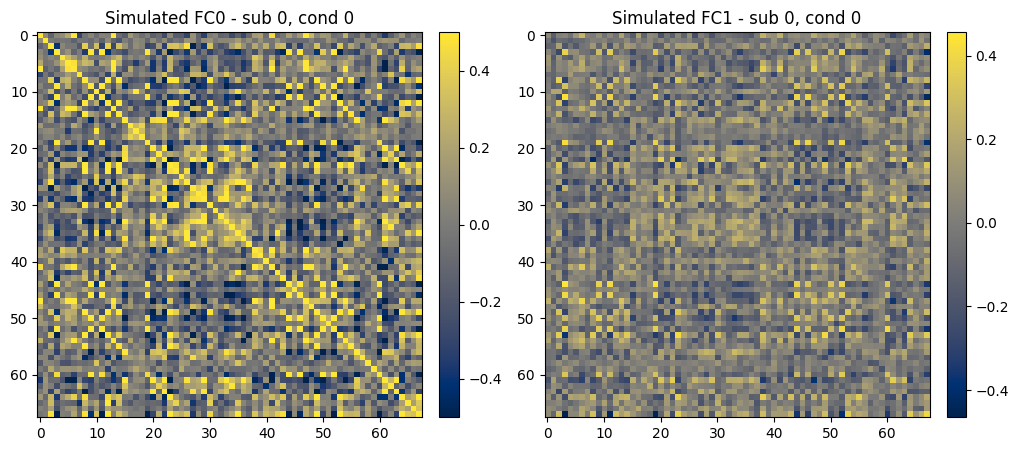

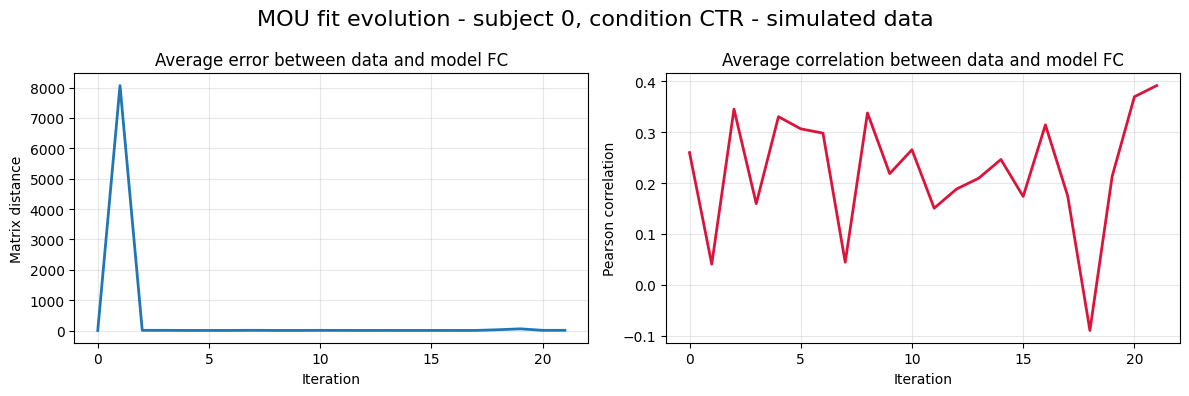

Q_data_temp shape: (2, 68, 68)
FC0 shape: (68, 68)
FC1 shape: (68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688
sub 0 ; cond 1 : {'n_tau': 2, 'iterations': 22, 'distance': np.float64(0.9350816915986262), 'correlation': np.float64(0.27968403806438247), 'distance history': array([  0.93508169, 202.14109879,   2.06825326, ...,   0.        ,
         0.        ,   0.        ]), 'correlation history': array([0.27968404, 0.13656264, 0.26778617, ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(1.3512537811750844), 'distFC1': np.float64(3.430366574742971)}


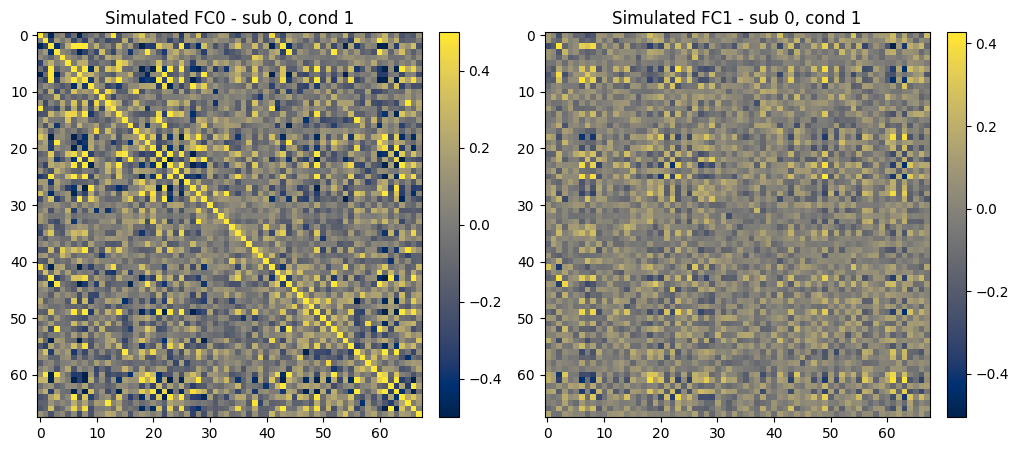

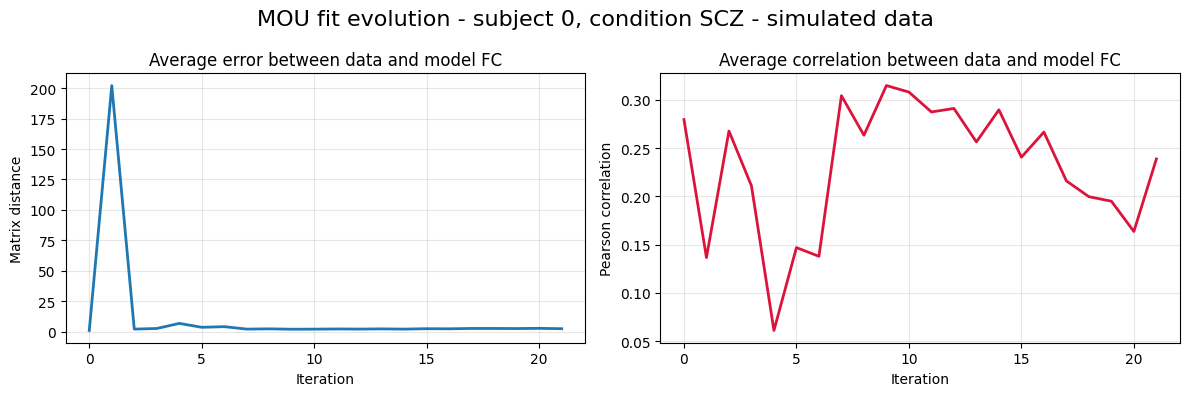

100%|██████████| 1/1 [00:03<00:00,  3.67s/it]

Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 1.0804441326366976
Mean distance FC1: 7.83443877786098


In [208]:
min_val_EC = 0. # minimal value for EC
max_val_EC = 1. # maximal value for EC
min_val_Sigma = 0. # minimal value for Sigma

# arrays to store results
var_BOLD = np.zeros([n_sub,n_cond,N]) # empirical BOLD variance
J_mod = np.zeros([n_sub,n_cond,N,N]) # model Jacobian (EC.) In the article of Entropy production B=-J
Sigma_mod = np.zeros([n_sub,n_cond,N,N]) # model sigma. In the article of Entropy production sigma=2D
FC0_mod = np.zeros([n_sub,n_cond,N,N]) # model zero-lad FC
err_mod = np.zeros([n_sub,n_cond]) # model error
fit_mod = np.zeros([n_sub,n_cond]) # model goodness of fit (Pearson corr)

verbose=True

## TEST : change min_iter
min_iter = 20
## END TEST 

# Initialize average FC0 and FC1 distance
avg_dist_FC0 = 0.0
avg_dist_FC1 = 0.0

# loop over subject and conditions
for i_sub in tqdm.tqdm(range(n_sub)):
    for i_cond in range(n_cond):
        # get time series
        Q_data_temp = Q_data[:,i_sub,:,:,i_cond]
        print("Q_data_temp shape:", Q_data_temp.shape)
        # store empirical BOLD variance (48, 68, 152, 2)
        #FC0 = Q_data_temp[0]
        #FC1 = Q_data_temp[1]
        FC0 = np.corrcoef(new_array[i_sub,:,:,i_cond]) 
        FC1 = FC0/np.max(FC0)
        ## debugging
        #FC0 = FC0 + np.eye(N)
        #FC1 = FC1 + np.eye(N)
        #Q_data_temp[0] = FC0
        #Q_data_temp[1] = FC1
        print("FC0 shape:", FC0.shape)
        print("FC1 shape:", FC1.shape)
        # 1) Basic sanity checks
        assert np.isfinite(FC0).all(), f"Non-finite values in FC0 at sub {i_sub}, cond {i_cond}"
        assert np.isfinite(FC1).all(), f"Non-finite values in FC1 at sub {i_sub}, cond {i_cond}"

        sym0 = np.max(np.abs(FC0 - FC0.T))
        sym1 = np.max(np.abs(FC1 - FC1.T))
        print(f"sub {i_sub}, cond {i_cond}: max asymmetry FC0={sym0:.3e}, FC1={sym1:.3e}")
        print("Q0 finite:", np.isfinite(FC0).all())
        print("Q1 finite:", np.isfinite(FC1).all())
        print("Q0 symmetric max err:", np.max(np.abs(FC0 - FC0.T)))
        print("Q1 diagonal min/max:", np.min(np.diag(FC1)), np.max(np.diag(FC1)))
        print("Q1 positive diagonal fraction:", np.mean(np.diag(FC1) > 0))
        print("Q0 norm:", np.linalg.norm(FC0))
        print("Q1 norm:", np.linalg.norm(FC1))
        ##
        lim_FC = 0.1 # limit DTI value to determine SC (only connections with larger values are tuned)
        mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
        mask_EC[FC1>lim_FC] = True
        for i in range(N):
            mask_EC[i,i] = False # no self connection
            mask_EC[i,N-1-i] = True # additional interhemispherical connections
        ##debugging
        fig_dbg, ax_dbg = plt.subplots(1, 2, figsize=(12, 5))
        ax_dbg[0].imshow(Q_data_temp[0], vmin=-0.5, vmax=0.5, cmap='bwr')
        # add a colorbar
        plt.colorbar(ax_dbg[0].imshow(Q_data_temp[0], vmin=-0.5, vmax=0.5, cmap='cividis'), ax=ax_dbg[0], fraction=0.046, pad=0.04)
        ax_dbg[0].set_title(f"{situations[situation_idx].capitalize()} FC0 - sub {i_sub}, cond {i_cond}")
        ax_dbg[1].imshow(Q_data_temp[1], cmap='bwr')
        ax_dbg[1].set_title(f"{situations[situation_idx].capitalize()} FC1 - sub {i_sub}, cond {i_cond}")
        # add a colorbar
        plt.colorbar(ax_dbg[1].imshow(Q_data_temp[1], cmap='cividis'), ax=ax_dbg[1], fraction=0.046, pad=0.04)
        #
        # invert model
        mou_est = MOUv2()
        mou_est.fit_Q(Q_emp = Q_data_temp, mask_C=mask_EC, mask_Sigma=mask_Sigma, algo_version="true", min_iter=min_iter, epsilon_C=0.005, epsilon_Sigma=0.005*N) #, verbose=True)

        # test : save nb of iterations
        iter_mod[i_sub, i_cond] = mou_est.d_fit["iterations"]

        # store results
        J_mod[i_sub,i_cond,:,:] = mou_est.J
        Sigma_mod[i_sub,i_cond,:,:] = mou_est.Sigma
        FC0_mod[i_sub,i_cond,:,:] = spl.solve_lyapunov(J_mod[i_sub,i_cond,:,:].T, -Sigma_mod[i_sub,i_cond,:,:])
        err_mod[i_sub,i_cond] = mou_est.d_fit['distance']
        fit_mod[i_sub,i_cond] = mou_est.d_fit['correlation']
        
        # Update average distances for FC0 and FC1
        avg_dist_FC0 += mou_est.d_fit['distFC0']
        avg_dist_FC1 += mou_est.d_fit['distFC1']

        if verbose:
            print('sub', i_sub, '; cond', i_cond, ':', mou_est.d_fit)
            
            d = mou_est.d_fit
            n_it = int(d["iterations"])

            # Error btw model and data for FC0 and FC1 (matrix distance) -> = 0.5 * (dist_Q0 + dist_Qtau)
            dist_hist = np.asarray(d["distance history"][:n_it])
            # Corr between model and empirical data for FC0 and FC1 -> =  0.5 * (Pearson_Q0  + Pearson_Qtau)
            corr_hist = np.asarray(d["correlation history"][:n_it])

            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
            ax[0].plot(dist_hist, lw=2)
            ax[0].set_title("Average error between data and model FC")
            ax[0].set_xlabel("Iteration")
            ax[0].set_ylabel("Matrix distance")
            ax[0].grid(alpha=0.3)

            ax[1].plot(corr_hist, lw=2, color="crimson")
            ax[1].set_title("Average correlation between data and model FC")
            
            ax[1].set_xlabel("Iteration")
            ax[1].set_ylabel("Pearson correlation")
            ax[1].grid(alpha=0.3)

            plt.suptitle(f"MOU fit evolution - subject {i_sub}, condition {conds[i_cond]} - {situations[situation_idx]} data", fontsize=16)
            plt.tight_layout()
            # Save figure
            plt.savefig(os.path.join(presentation_figs_dir, f"MOU_fit_evolution_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}"), format=graph_format, dpi=300)
            plt.show()
            plt.close()
            
print("Mean iterations:", iter_mod.mean())
print("Max iterations:", iter_mod.max())
print("Mean distance FC0:", avg_dist_FC0 / (n_sub * n_cond))
print("Mean distance FC1:", avg_dist_FC1 / (n_sub * n_cond))

### End of test

#### Test goodness of fit

C:\Users\Bruna\AppData\Local\Temp\ipykernel_18252\3228635675.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_18252\3228635675.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_18252\3228635675.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=fit_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_18252\3228635675.py:42: UserWarning: The palet

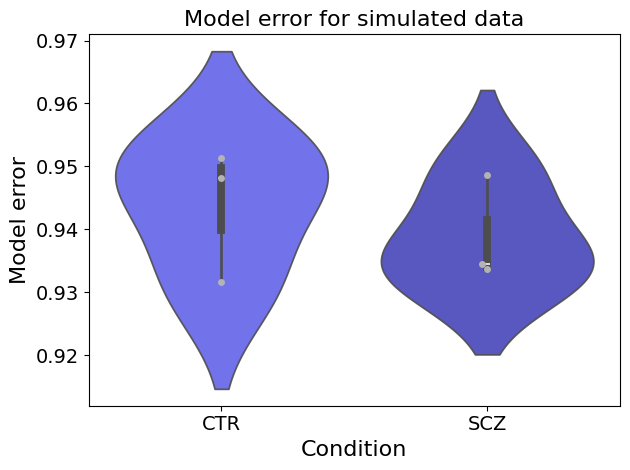

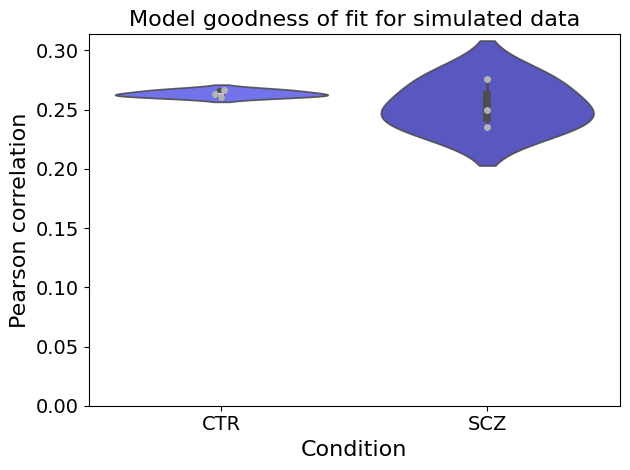

In [187]:
mask_diag = np.eye(N, dtype=bool) # mask for diagonal elements

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]] # colors

# Model error computation
err_mod_tmp = dict()
err_mod_tmp['sum EC'] = err_mod.flatten()
err_mod_tmp['sub'] = np.repeat(np.arange(n_sub), n_cond).flatten()
err_mod_tmp['cond'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()

err_mod_df = pd.DataFrame(err_mod_tmp)

# Model error plot
plt.figure()
sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
sb.swarmplot(data=err_mod_df, x='cond', y='sum EC', color=[0.7,0.7,0.7])
#plt.axis(ymin=0, ymax=0.8)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model error for {situations[situation_idx]} data', fontsize=16)
plt.xlabel('Condition',fontsize=16)
plt.ylabel('Model error',fontsize=16)

plt.tight_layout()
# Save figure
fig_path = os.path.join(presentation_figs_dir, f'MOU_model_error_{situations[situation_idx]}.{graph_format}')
#plt.savefig(res_dir+'model_fit_error.eps', format='eps')
plt.savefig(fig_path, dpi=300)


# Pearson correlation
fit_mod_tmp = dict()
fit_mod_tmp['sum EC'] = fit_mod.flatten()
fit_mod_tmp['sub'] = np.repeat(np.arange(n_sub), n_cond).flatten()
fit_mod_tmp['cond'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()

fit_mod_df = pd.DataFrame(fit_mod_tmp)

# Correlation violin plot
plt.figure()
sb.violinplot(data=fit_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
sb.swarmplot(data=fit_mod_df, x='cond', y='sum EC', color=[0.7,0.7,0.7])
plt.axis(ymin=0)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model goodness of fit for {situations[situation_idx]} data',fontsize=16)
plt.xlabel('Condition',fontsize=16)
plt.ylabel('Pearson correlation',fontsize=16)
plt.tight_layout()

# Save figure
fig_path = os.path.join(presentation_figs_dir, f'MOU_model_goodness_fit_{situations[situation_idx]}.{graph_format}')
plt.savefig(fig_path, dpi=300)


# Example EC

# plt.figure(figsize=(5,4))
# plt.imshow(np.maximum(J_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
# #plt.imshow(J_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
# plt.colorbar()
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel('Target ROI index', fontsize=16)
# plt.ylabel('Source ROI index', fontsize=16)
# plt.tight_layout()
# plt.savefig(res_dir+'example_EC.eps', format='eps')

# # Example EC

# plt.figure(figsize=(5,4))
# #plt.imshow(np.maximum(Sigma_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
# plt.imshow(Sigma_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
# plt.colorbar()
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel('Target ROI index', fontsize=16)
# plt.ylabel('Source ROI index', fontsize=16)
# plt.tight_layout()
# plt.savefig(res_dir+'example_EC.eps', format='eps')

In [132]:
# Print average pearson correlation for each condition
print(f"Average Pearson correlation between model and data FC\n")
print(f"Controls: {fit_mod_df[fit_mod_df['cond'] == 'CTR']['sum EC'].mean():.4f}")
print(f"Schizophrenia: {fit_mod_df[fit_mod_df['cond'] == 'SCZ']['sum EC'].mean():.4f}")

Average Pearson correlation between model and data FC

Controls: 0.2610
Schizophrenia: 0.2643


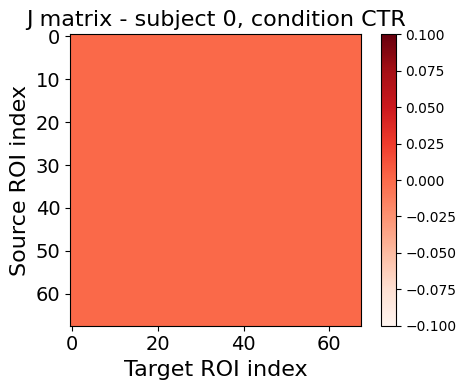

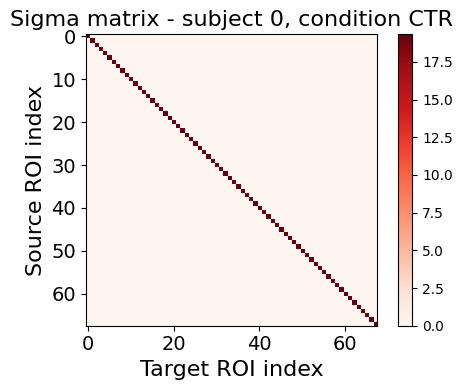

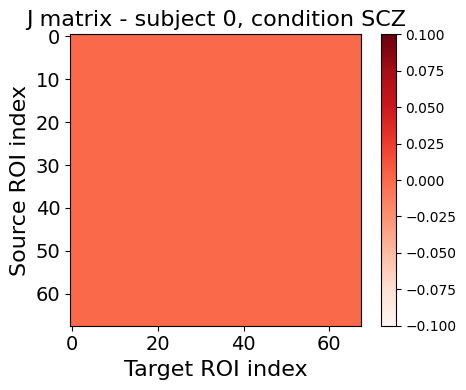

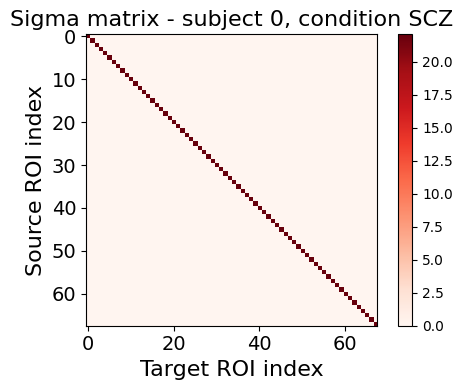

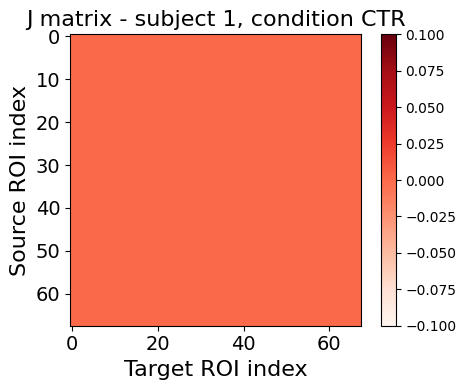

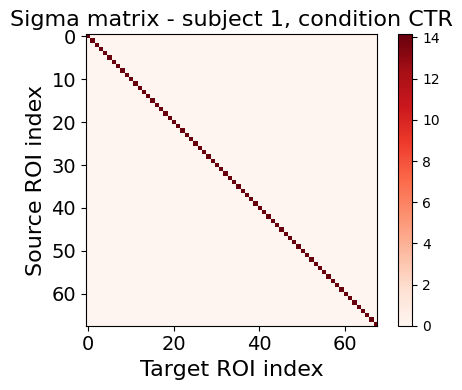

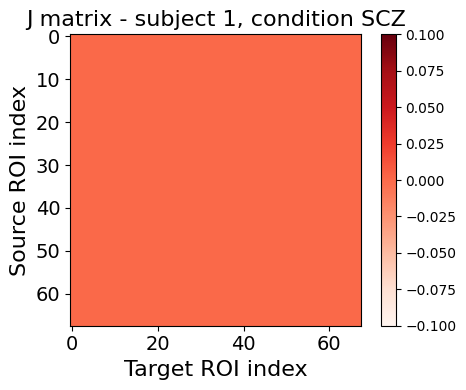

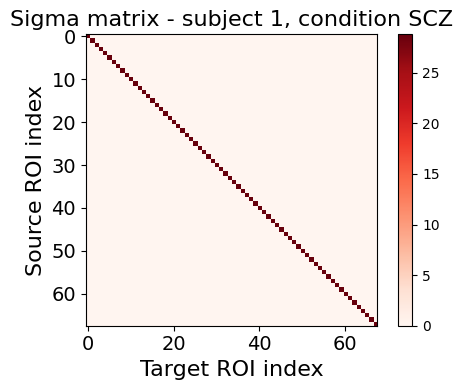

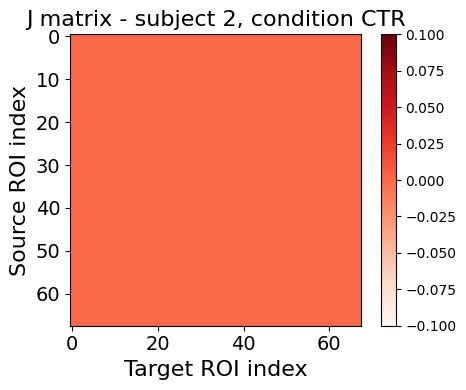

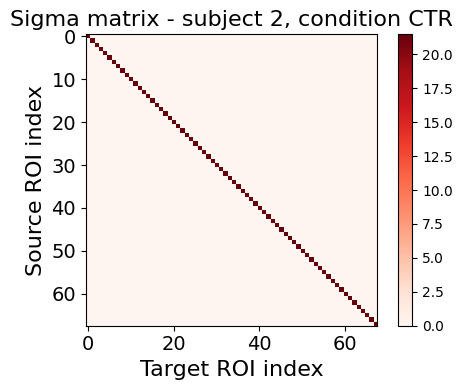

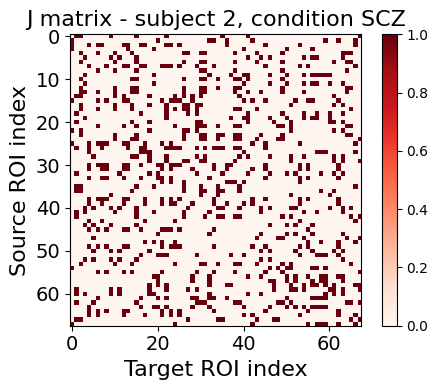

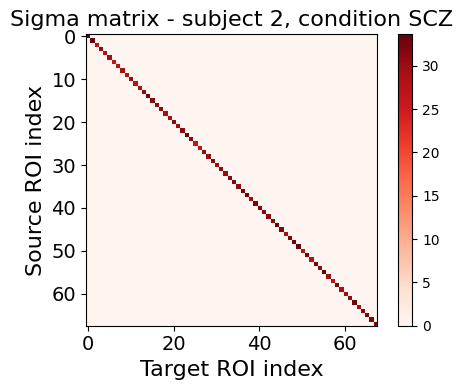

In [135]:
for i_sub in range(n_sub):
    for i_cond in range(n_cond):
        J = J_mod[i_sub, i_cond, :, :]
        Sigma = Sigma_mod[i_sub, i_cond, :, :]
        FC0 = FC0_mod[i_sub, i_cond, :, :]

        # Plotting the jacobian for one subject and conditon
        plt.figure(figsize=(5,4))
        plt.imshow(np.maximum(J_mod[i_sub,i_cond,:,:],0), cmap='Reds')   # Show only the non-negatives
        #plt.imshow(J_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
        plt.colorbar()
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.title(f"J matrix - subject {i_sub}, condition {conds[i_cond]}", fontsize=16)
        plt.xlabel('Target ROI index', fontsize=16)
        plt.ylabel('Source ROI index', fontsize=16)
        plt.tight_layout()
        #plt.savefig(res_dir+'example_EC.eps', format='eps')
        # Save figure
        fig_path = os.path.join(presentation_figs_dir, f'MOU_J_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}')
        plt.savefig(fig_path, dpi=300)

        ## Plotting sigma for one subject and condition
        plt.figure(figsize=(5,4))
        #plt.imshow(np.maximum(Sigma_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
        plt.imshow(Sigma_mod[i_sub,i_cond,:,:], cmap='Reds')   # Show only the non-negatives
        plt.colorbar()
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.title(f"Sigma matrix - subject {i_sub}, condition {conds[i_cond]}", fontsize=16)
        plt.xlabel('Target ROI index', fontsize=16)
        plt.ylabel('Source ROI index', fontsize=16)
        plt.tight_layout()
        # Save figure
        fig_path = os.path.join(presentation_figs_dir, f'MOU_Sigma_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}')
        plt.savefig(fig_path, dpi=300)

#### Entropy production rate calculation

In [71]:
# transpose to Saclay's framework
EPR = np.zeros([n_sub,n_cond])
Q_indiv = np.zeros([n_sub,n_cond,N,N])

for i_sub in range(n_sub):
    for i_cond in range(n_cond):

        try:
            B = np.copy(-J_mod[i_sub,i_cond,:,:].T) # B=-J
            D = np.copy(0.5 * Sigma_mod[i_sub,i_cond,:,:]) # D=1/2 * Sigma
            S = np.copy(FC0_mod[i_sub,i_cond,:,:])
            
            Q = np.dot(B, S) - D
            Q_indiv[i_sub,i_cond,:,:] = Q
            
            # sanity check
            if True:
                print('should be close to zero:', np.abs(np.dot(B,S) + np.dot(S,B.T) -2*D).max())
            
            # formula from Godreche Luck
            Dinv = np.linalg.pinv(D)
            Sinv = np.linalg.pinv(S)
            
            entropy_prod_rate = -np.trace(np.dot(np.dot(np.dot(Sinv, Q), Dinv), Q))  #-tr(S^(-1)*Q*D^(-1)*Q)
            EPR[i_sub,i_cond] = entropy_prod_rate

        except:
            print('problem with subject/cond:', i_sub, i_cond)
       

#np.save(res_dir+'EPR.npy',EPR)



should be close to zero: 7.549516567451064e-15
should be close to zero: 2.7533531010703882e-14
should be close to zero: 7.549516567451064e-15
should be close to zero: 2.3092638912203256e-14
should be close to zero: 1.5987211554602254e-14
should be close to zero: 1.5987211554602254e-14


C:\Users\Bruna\AppData\Local\Temp\ipykernel_5516\2813494162.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_5516\2813494162.py:22: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)


Text(40.222222222222214, 0.5, 'Entropy production rate')

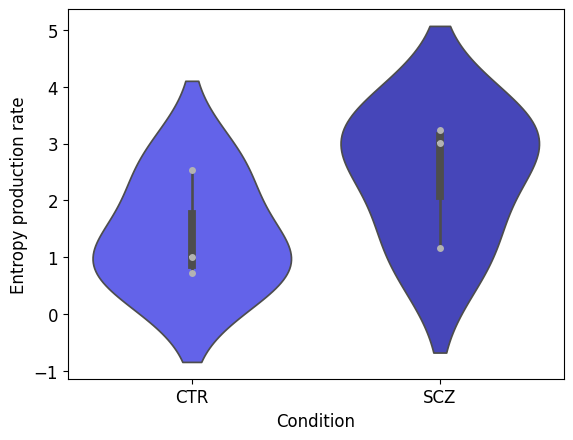

In [72]:
#%% plots

matplotlib.rc('font', size=12) 
matplotlib.rc('xtick', labelsize=12)
matplotlib.rc('ytick', labelsize=12)

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]]
cols2 = [[0.7,0.7,1],[0.6,0.6,1],[0.5,0.5,1],[0.4,0.4,1]]

EPR_tmp = dict()
EPR_tmp['sleep stage'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()
EPR_tmp['EPR'] = EPR.flatten()

EPR_df = pd.DataFrame(EPR_tmp)

#EPR_df=EPR_df.drop(index=13)


# real data

plt.figure()
ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)
sb.swarmplot(data=EPR_df, x='sleep stage', y='EPR', color=[0.7,0.7,0.7])
#plt.axis(ymin=-1.2, ymax=10)

plt.xlabel('Condition', fontsize=12)
plt.ylabel('Entropy production rate', fontsize=12)

#plt.savefig(res_dir+'entropy_prod_rate.eps', format='eps')

C:\Users\Bruna\AppData\Local\Temp\ipykernel_30792\2658677989.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data,


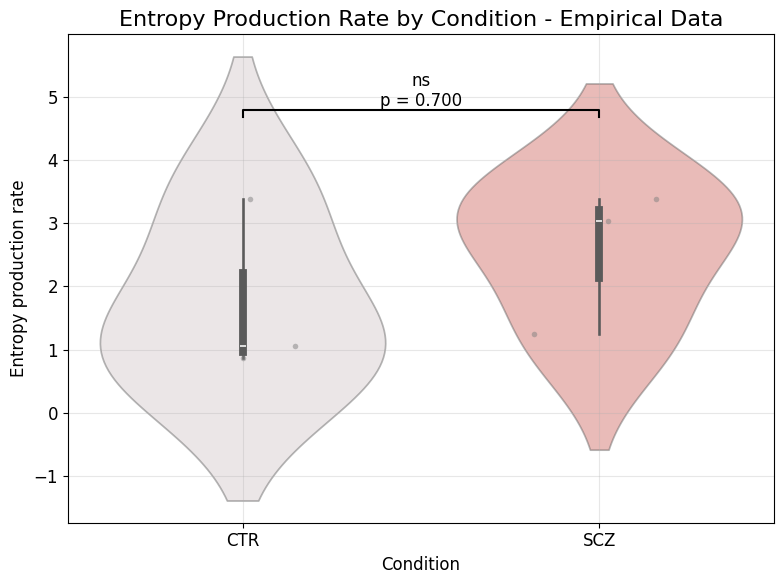


Statistical Test Results:
Mann-Whitney U test statistic: 3.00
p-value: 0.700


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Create sample data (replace with your actual data)
data = pd.DataFrame({
    'Condition': ['CTR']*n_sub + ['SCZ']*n_sub,
    'Entropy_production_rate': np.concatenate([
        EPR_df[EPR_df['sleep stage'] == 'CTR']['EPR'].tolist(),
        EPR_df[EPR_df['sleep stage'] == 'SCZ']['EPR'].tolist()
    ])
})

# Perform statistical test
ctr_data = data[data['Condition'] == 'CTR']['Entropy_production_rate']
scz_data = data[data['Condition'] == 'SCZ']['Entropy_production_rate']

# Perform Mann-Whitney U test (non-parametric test for independent samples)
statistic, p_value = stats.mannwhitneyu(ctr_data, scz_data, alternative='two-sided')

# Colors 
palette = {'CTR': '#D4C6C9', 'SCZ': '#E1544C'}

# Create the figure
plt.figure(figsize=(8, 6))

# Create violin plot
sns.violinplot(data=data, 
               x='Condition', 
               y='Entropy_production_rate',
               palette = palette,
               alpha=0.44)

# Add strip plot (individual points)
sns.stripplot(data=data,
             x='Condition',
             y='Entropy_production_rate',
             color='gray',
             alpha=0.5,
             jitter=0.2,
             size=4)

# Add significance bar
def add_stat_annotation(p_value):
    # Define the significance level markers
    if p_value < 0.001:
        star_string = '***'
    elif p_value < 0.01:
        star_string = '**'
    elif p_value < 0.05:
        star_string = '*'
    else:
        star_string = 'ns'
    
    # Get y coordinates for the bar
    y_max = data['Entropy_production_rate'].max()
    bar_height = y_max + 1.3
    
    # Plot the significance bar
    x1, x2 = 0, 1  # x-coordinates for CTR and SCZ
    bar_height_diff = 0.1
    
    plt.plot([x1, x1, x2, x2], 
            [bar_height, bar_height + bar_height_diff, bar_height + bar_height_diff, bar_height],
            'k-', linewidth=1.5)
    
    # Add star annotation
    plt.text((x1 + x2) * 0.5, bar_height + bar_height_diff,
            f'{star_string}\np = {p_value:.3f}',
            ha='center', va='bottom')

# Add the significance annotation
add_stat_annotation(p_value)

# Customize the plot
plt.title(f'Entropy Production Rate by Condition - {situations[situation_idx].capitalize()} Data', fontsize=16)
plt.xlabel('Condition')
plt.ylabel('Entropy production rate')
#plt.ylim(4, 14)  # Adjust the upper limit if needed to show the significance bar
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

#plt.savefig(res_dir+'entropy_prod_rate_statbar.png', format='png', dpi=300)
fig_path = os.path.join(presentation_figs_dir, f'entropy_prod_rate_statbar_{situations[situation_idx]}.{graph_format}')
plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()

# Print statistical test results
print(f'\nStatistical Test Results:')
print(f'Mann-Whitney U test statistic: {statistic:.2f}')
print(f'p-value: {p_value:.3f}')

### Grid search for better hyperparameters for MOU fitting

In [ ]:
# Parameter sweep for MOUv2.fit (Lyapunov)
# Goal: improve distance, correlation, and especially distFC1.
from itertools import product
import numpy as np
import pandas as pd
import tqdm

# 1) Define which subject/condition pairs to use for tuning (keep small for speed)
max_sub_for_sweep = min(n_sub, 2)  # increase to n_sub for full sweep
eval_pairs = [(i_sub, i_cond) for i_sub in range(max_sub_for_sweep) for i_cond in range(n_cond)]
print("Sweep will evaluate pairs:", eval_pairs)

# 2) Hyperparameter grid
grid = {
    "algo_version": ["NeNe2020", "PCB2016"],
    "epsilon_C": [5e-4, 1e-3, 2e-3],
    "epsilon_Sigma": [5e-3, 1e-2, 2e-2],
    "regul_C": [0.0, 0.05, 0.1],
    "regul_Sigma": [0.0, 1e-3],
    "min_iter": [30, 50, 100],
    "max_iter": [2000],     # keep fixed for fair comparison
    "lim_FC": [0.05, 0.1],  # threshold used to build mask_EC from FC
}

keys = list(grid.keys())
values = [grid[k] for k in keys]
n_combos = int(np.prod([len(v) for v in values]))
print("Total parameter combinations:", n_combos)

records = []

for combo in tqdm.tqdm(product(*values), total=n_combos):
    params = dict(zip(keys, combo))

    dist_list = []
    corr_list = []
    distFC0_list = []
    distFC1_list = []
    iter_list = []
    fail_count = 0

    for i_sub, i_cond in eval_pairs:
        ts = new_array[i_sub, :, :, i_cond]  # shape: nodes x time

        # Rebuild EC mask exactly as in your main loop, but with sweepable lim_FC
        FC0 = np.corrcoef(ts)
        FC1 = FC0 / np.max(np.abs(FC0))
        mask_EC_local = np.zeros((N, N), dtype=bool)
        mask_EC_local[FC1 > params["lim_FC"]] = True
        for i in range(N):
            mask_EC_local[i, i] = False
            mask_EC_local[i, N - 1 - i] = True

        mou_est = MOUv2()
        try:
            mou_est.fit(
                ts.T,
                mask_C=mask_EC_local,
                mask_Sigma=mask_Sigma,
                algo_version=params["algo_version"],
                min_iter=params["min_iter"],
                max_iter=params["max_iter"],
                epsilon_C=params["epsilon_C"],
                epsilon_Sigma=params["epsilon_Sigma"],
                regul_C=params["regul_C"],
                regul_Sigma=params["regul_Sigma"],
                verbose=False,
            )
            d = mou_est.d_fit
            dist_list.append(float(d["distance"]))
            corr_list.append(float(d["correlation"]))
            distFC0_list.append(float(d.get("distFC0", np.nan)))
            distFC1_list.append(float(d.get("distFC1", np.nan)))
            iter_list.append(int(d["iterations"]))
        except Exception:
            fail_count += 1

    n_ok = len(dist_list)
    if n_ok == 0:
        continue

    records.append({
        "algo_version": params["algo_version"],
        "epsilon_C": params["epsilon_C"],
        "epsilon_Sigma": params["epsilon_Sigma"],
        "regul_C": params["regul_C"],
        "regul_Sigma": params["regul_Sigma"],
        "min_iter": params["min_iter"],
        "max_iter": params["max_iter"],
        "lim_FC": params["lim_FC"],
        "n_ok": n_ok,
        "n_fail": fail_count,
        "mean_distance": np.mean(dist_list),
        "std_distance": np.std(dist_list),
        "mean_corr": np.mean(corr_list),
        "std_corr": np.std(corr_list),
        "mean_distFC0": np.nanmean(distFC0_list),
        "mean_distFC1": np.nanmean(distFC1_list),
        "mean_iter": np.mean(iter_list),
        "max_iter_used": np.max(iter_list),
    })

results = pd.DataFrame(records)

# Ranking rule: prioritize lower distance and lower distFC1, then higher correlation
results = results.sort_values(
    by=["mean_distance", "mean_distFC1", "mean_corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\nTop 10 parameter sets:")
display(results.head(10))

best = results.iloc[0]
best_fit_kwargs = {
    "algo_version": best["algo_version"],
    "epsilon_C": float(best["epsilon_C"]),
    "epsilon_Sigma": float(best["epsilon_Sigma"]),
    "regul_C": float(best["regul_C"]),
    "regul_Sigma": float(best["regul_Sigma"]),
    "min_iter": int(best["min_iter"]),
    "max_iter": int(best["max_iter"]),
}
best_lim_FC = float(best["lim_FC"])

print("\nBest fit kwargs for your main loop:")
print(best_fit_kwargs)
print("Best lim_FC:", best_lim_FC)

Sweep will evaluate pairs: [(0, 0), (0, 1), (1, 0), (1, 1)]
Total parameter combinations: 648


  0%|          | 3/648 [00:51<3:05:15, 17.23s/it]


KeyboardInterrupt: 

In [ ]:
# Refit full dataset with best grid-search parameters
import numpy as np
import pandas as pd
import scipy.linalg as spl
import tqdm

best = results.iloc[0]
best_fit_kwargs = {
    "algo_version": best["algo_version"],
    "epsilon_C": float(best["epsilon_C"]),
    "epsilon_Sigma": float(best["epsilon_Sigma"]),
    "regul_C": float(best["regul_C"]),
    "regul_Sigma": float(best["regul_Sigma"]),
    "min_iter": int(best["min_iter"]),
    "max_iter": int(best["max_iter"]),
}
best_lim_FC = float(best["lim_FC"])

print("Best parameters:")
print(best_fit_kwargs)
print("best_lim_FC:", best_lim_FC)

# Keep current results as baseline if they exist
err_mod_baseline = None
fit_mod_baseline = None
iter_mod_baseline = None

# New arrays for best run
var_BOLD_best = np.zeros((n_sub, n_cond, N))
J_mod_best = np.zeros((n_sub, n_cond, N, N))
Sigma_mod_best = np.zeros((n_sub, n_cond, N, N))
FC0_mod_best = np.zeros((n_sub, n_cond, N, N))
err_mod_best = np.zeros((n_sub, n_cond))
fit_mod_best = np.zeros((n_sub, n_cond))
iter_mod_best = np.zeros((n_sub, n_cond), dtype=int)
distFC0_best = np.zeros((n_sub, n_cond))
distFC1_best = np.zeros((n_sub, n_cond))

for i_sub in tqdm.tqdm(range(n_sub), desc="Refit with best params"):
    for i_cond in range(n_cond):
        ts = new_array[i_sub, :, :, i_cond]
        var_BOLD_best[i_sub, i_cond, :] = ts.var(axis=1)

        FC0 = np.corrcoef(ts)
        FC1 = FC0 / np.max(np.abs(FC0))
        mask_EC_local = np.zeros((N, N), dtype=bool)
        mask_EC_local[FC1 > best_lim_FC] = True
        for i in range(N):
            mask_EC_local[i, i] = False
            mask_EC_local[i, N - 1 - i] = True

        mou_est = MOUv2()
        mou_est.fit(
            ts.T,
            mask_C=mask_EC_local,
            mask_Sigma=mask_Sigma,
            verbose=False,
            **best_fit_kwargs
        )

        d = mou_est.d_fit
        J_mod_best[i_sub, i_cond, :, :] = mou_est.J
        Sigma_mod_best[i_sub, i_cond, :, :] = mou_est.Sigma
        FC0_mod_best[i_sub, i_cond, :, :] = spl.solve_lyapunov(
            J_mod_best[i_sub, i_cond, :, :].T, -Sigma_mod_best[i_sub, i_cond, :, :]
        )
        err_mod_best[i_sub, i_cond] = float(d["distance"])
        fit_mod_best[i_sub, i_cond] = float(d["correlation"])
        iter_mod_best[i_sub, i_cond] = int(d["iterations"])
        distFC0_best[i_sub, i_cond] = float(d.get("distFC0", np.nan))
        distFC1_best[i_sub, i_cond] = float(d.get("distFC1", np.nan))

# Quick summary
summary_rows = []

if err_mod_baseline is not None:
    summary_rows.append({
        "run": "baseline",
        "mean_distance": float(np.mean(err_mod_baseline)),
        "mean_corr": float(np.mean(fit_mod_baseline)),
        "mean_iter": float(np.mean(iter_mod_baseline)) if iter_mod_baseline is not None else np.nan,
    })

summary_rows.append({
    "run": "best_grid_params",
    "mean_distance": float(np.mean(err_mod_best)),
    "mean_corr": float(np.mean(fit_mod_best)),
    "mean_iter": float(np.mean(iter_mod_best)),
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("mean distFC0 (best):", float(np.nanmean(distFC0_best)))
print("mean distFC1 (best):", float(np.nanmean(distFC1_best)))

Best parameters:
{'algo_version': 'PCB2016', 'epsilon_C': 0.002, 'epsilon_Sigma': 0.01, 'regul_C': 0.1, 'regul_Sigma': 0.001, 'min_iter': 100, 'max_iter': 2000}
best_lim_FC: 0.1


Refit with best params: 100%|██████████| 3/3 [00:12<00:00,  4.03s/it]


,run,mean_distance,mean_corr,mean_iter
0,best_grid_params,0.767244,0.43538,102.0


mean distFC0 (best): 0.540366591522204
mean distFC1 (best): 0.9999267013397989


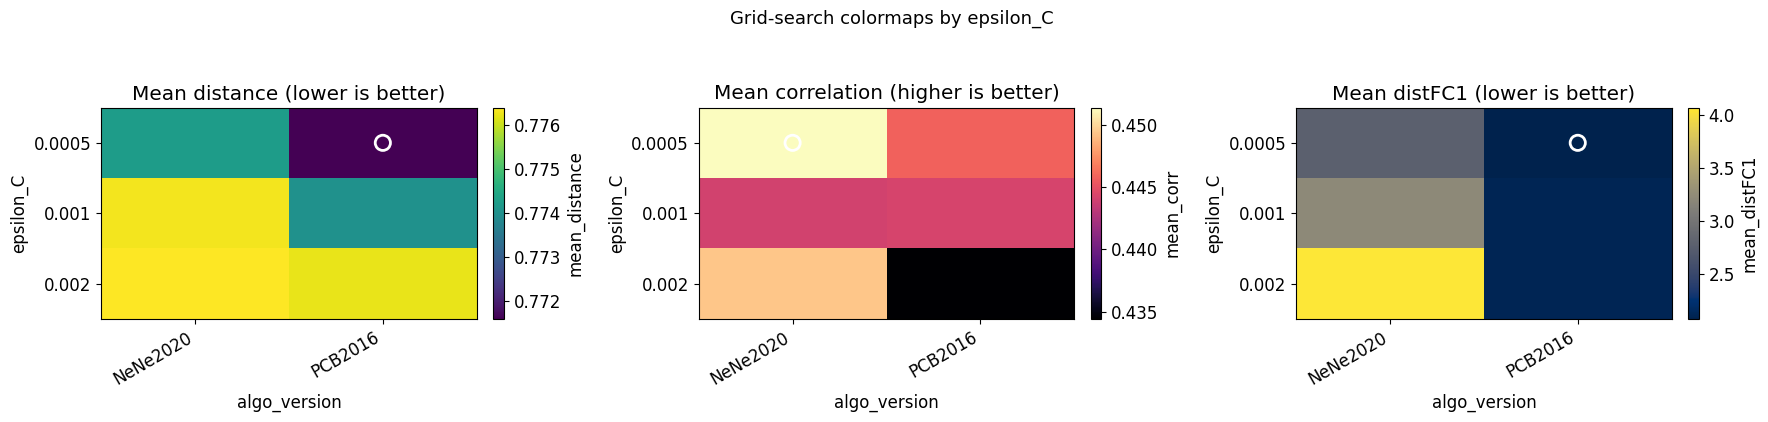

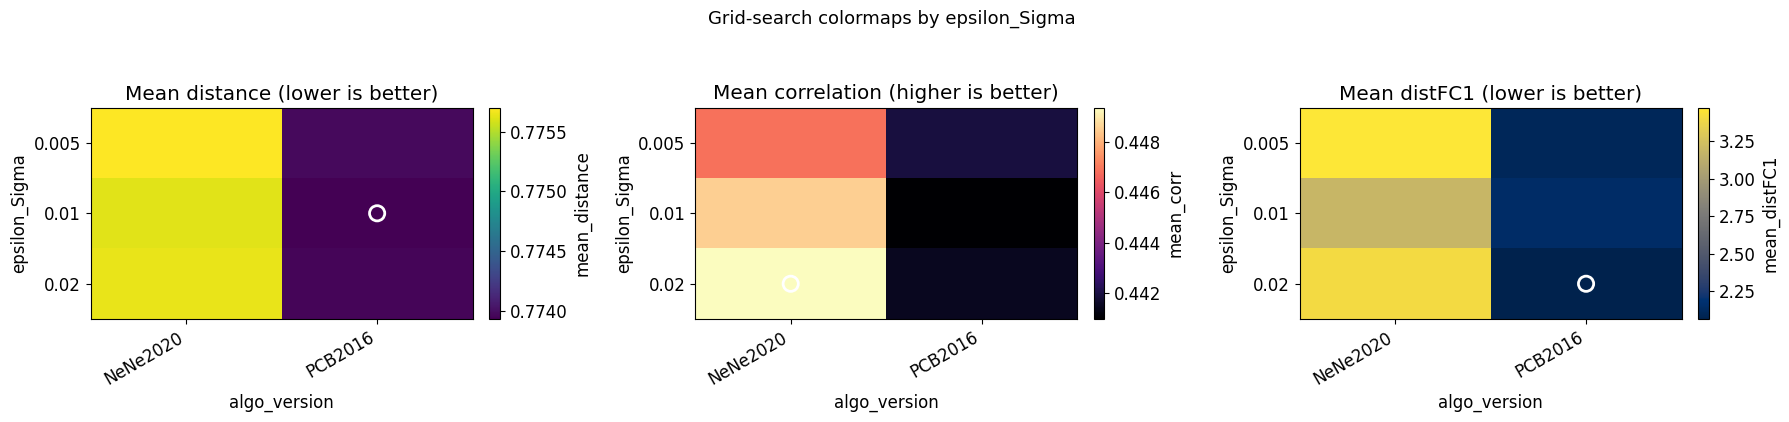

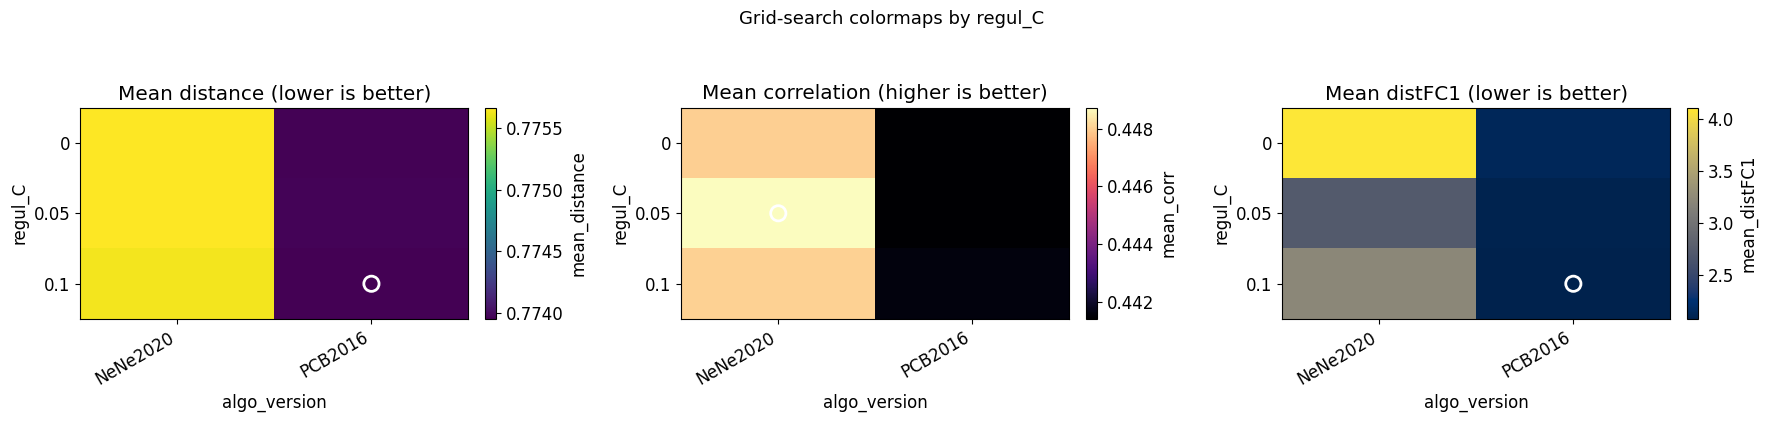

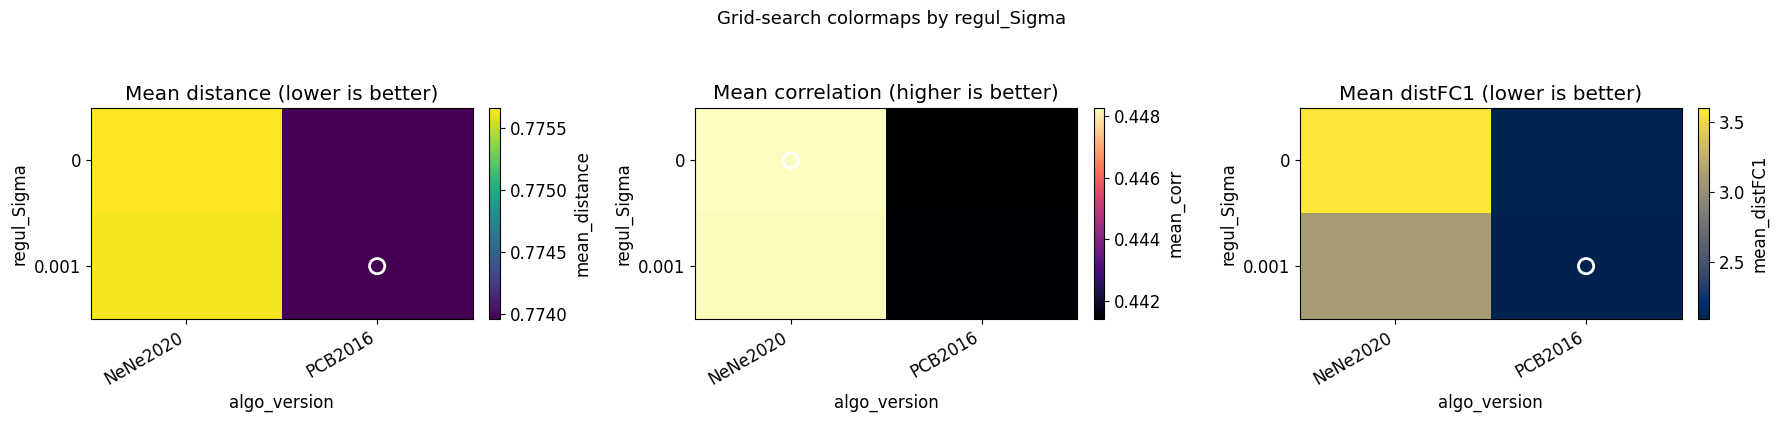

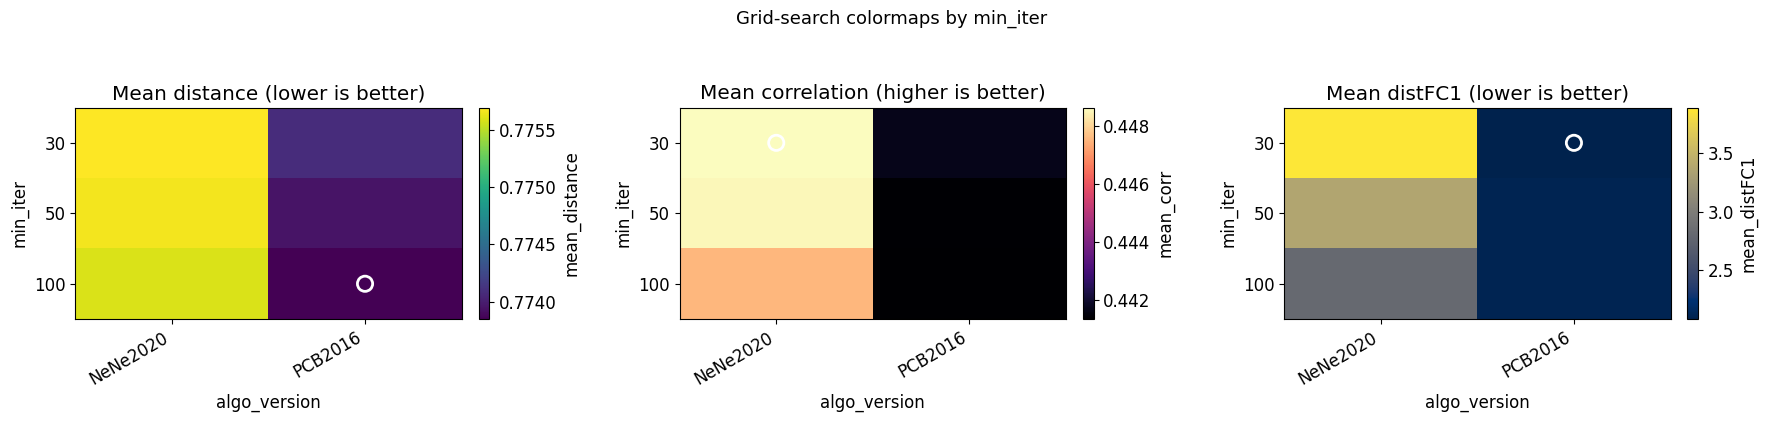

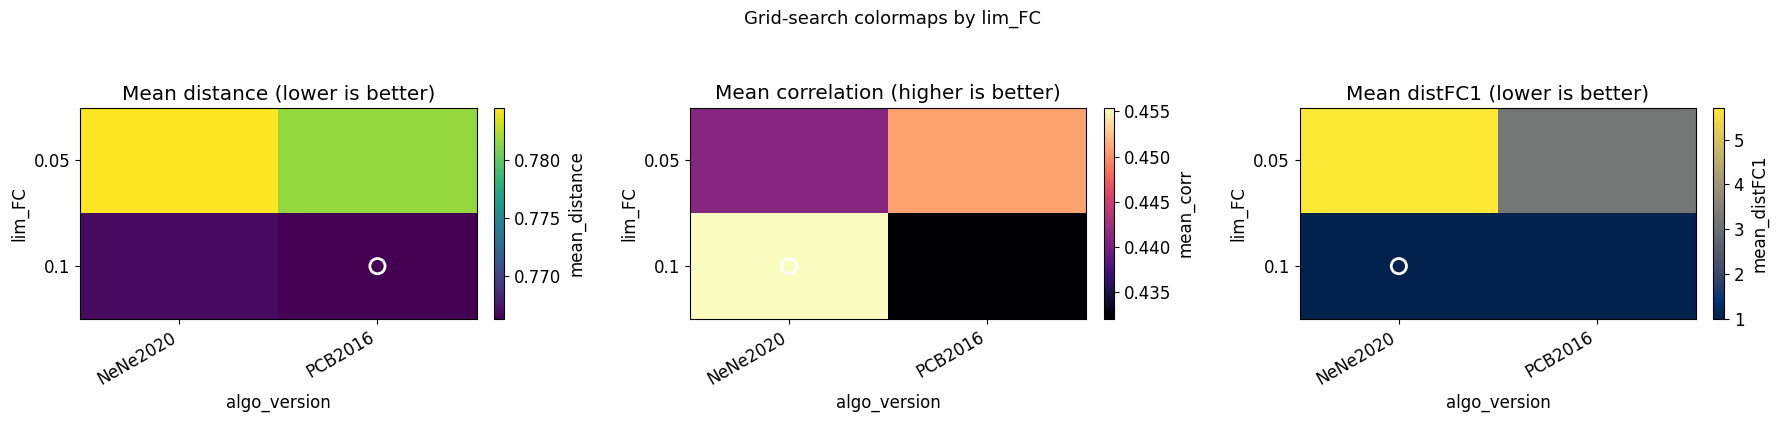

In [ ]:
# Colormap plots per parameter from grid-search results

#if "results" not in globals or results.empty:
 #   raise ValueError("No sweep results found. Run the grid-search cell first.")

params_to_plot = [
    "epsilon_C",
    "epsilon_Sigma",
    "regul_C",
    "regul_Sigma",
    "min_iter",
    "lim_FC",
]

metrics = [
    ("mean_distance", "Mean distance (lower is better)", "viridis", "min"),
    ("mean_corr", "Mean correlation (higher is better)", "magma", "max"),
    ("mean_distFC1", "Mean distFC1 (lower is better)", "cividis", "min"),
]

def _fmt(v):
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    return f"{float(v):.3g}"

for p in params_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, (metric, title, cmap, best_mode) in zip(axes, metrics):
        pt = results.pivot_table(
            index=p,
            columns="algo_version",
            values=metric,
            aggfunc="mean"
        ).sort_index()

        if pt.shape[0] == 0 or pt.shape[1] == 0:
            ax.set_axis_off()
            continue

        im = ax.imshow(pt.values, aspect="auto", cmap=cmap)

        ax.set_title(title)
        ax.set_xlabel("algo_version")
        ax.set_ylabel(p)
        ax.set_xticks(np.arange(len(pt.columns)))
        ax.set_xticklabels([str(c) for c in pt.columns], rotation=30, ha="right")
        ax.set_yticks(np.arange(len(pt.index)))
        ax.set_yticklabels([_fmt(v) for v in pt.index])

        # mark best cell on each heatmap
        vals = pt.values
        if best_mode == "min":
            iy, ix = np.unravel_index(np.nanargmin(vals), vals.shape)
        else:
            iy, ix = np.unravel_index(np.nanargmax(vals), vals.shape)
        ax.scatter(ix, iy, s=120, facecolors="none", edgecolors="white", linewidths=2)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.set_ylabel(metric, rotation=90)

    fig.suptitle(f"Grid-search colormaps by {p}", y=1.05, fontsize=13)
    plt.tight_layout()
    plt.show()